# 05 — XGBoost avec Optimisation Bayésienne (Optuna)
**Membre 3** | Credit Card Fraud Detection

### Ce notebook produit :
- Modèle XGBoost optimisé avec Optuna (TPE)
- `models/xgboost.pkl` — modèle sauvegardé
- Comparaison `scale_pos_weight` vs Loss Function asymétrique
- Graphiques de convergence Optuna (Optimization History + Objective Value)
- Métriques complètes : F1-Macro, AUPRC, MCC

### Plan :
1. Imports & Configuration
2. Chargement des données
3. Justification de XGBoost + Cost-Sensitive Learning
4. Stratégie 1 — `scale_pos_weight`
5. Stratégie 2 — Loss Function asymétrique (Focal Loss)
6. Comparaison des deux stratégies
7. Optimisation Bayésienne (Optuna / TPE) — meilleure stratégie
8. Analyse de la convergence Optuna
9. Évaluation complète du modèle final
10. Sauvegarde

> **Note :** Optuna avec `n_trials=50` prend environ 20-30 min sur CPU standard.  
> Réduire à `n_trials=30` si les ressources sont limitées.

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc
)
from sklearn.calibration import calibration_curve

# ── Config partagée ──────────────────────────────────────────────────────────
RANDOM_SEED  = 42
TRAIN_PATH   = '../data/processed/train.csv'
VAL_PATH     = '../data/processed/val.csv'
TEST_PATH    = '../data/processed/test.csv'
MODELS_PATH  = '../models/'
PLOTS_PATH   = '../plots/'
N_TRIALS     = 50   # Réduire à 30 si ressources limitées

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,  exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')
print(f'   XGBoost version : {xgb.__version__}')
print(f'   Optuna version  : {optuna.__version__}')

✅ Setup OK
   XGBoost version : 3.2.0
   Optuna version  : 4.8.0


---
## 1. Chargement des Données

In [2]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_val   = val.drop(columns=['Class'])
y_val   = val['Class']
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

# ── scale_pos_weight — calculé une seule fois ────────────────────────────────
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
SPW       = neg_count / pos_count

print('═══════════════════════════════════════════════')
print('           DONNÉES CHARGÉES                   ')
print('═══════════════════════════════════════════════')
for name, X, y in [('Train', X_train, y_train),
                    ('Val',   X_val,   y_val),
                    ('Test',  X_test,  y_test)]:
    print(f'  {name:<6}: {len(X):>8,} lignes | {y.sum():>4} fraudes ({y.mean()*100:.3f}%)')
print('═══════════════════════════════════════════════')
print(f'\n  scale_pos_weight recommandé : {SPW:.1f}')
print(f'  (ratio négatifs/positifs = {neg_count:,} / {pos_count:,})')

═══════════════════════════════════════════════
           DONNÉES CHARGÉES                   
═══════════════════════════════════════════════
  Train :  205,060 lignes |  355 fraudes (0.173%)
  Val   :   22,785 lignes |   39 fraudes (0.171%)
  Test  :   56,962 lignes |   98 fraudes (0.172%)
═══════════════════════════════════════════════

  scale_pos_weight recommandé : 576.6
  (ratio négatifs/positifs = 204,705 / 355)


---
## 2. Justification de XGBoost & Cost-Sensitive Learning

### Pourquoi XGBoost ?

XGBoost (Extreme Gradient Boosting) construit des arbres de décision de façon séquentielle :  
chaque arbre corrige les erreurs résiduelles du modèle précédent.

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot f_t(x)$$

Où $f_t$ est le $t$-ième arbre entraîné sur les **résidus** (gradients) de l'étape précédente.

**Avantages sur ce dataset :**
- Meilleure capture des interactions non-linéaires entre les features V1–V28 (PCA)
- Régularisation L1/L2 intégrée (`alpha`, `lambda`)
- Gestion native du déséquilibre via `scale_pos_weight`
- Entraînement rapide grâce à l'implémentation par histogrammes

### Deux stratégies Cost-Sensitive

| Stratégie | Mécanisme | Avantage |
|---|---|---|
| `scale_pos_weight` | Multiplie le gradient de la classe positive par `neg/pos` | Simple, efficace, recommandé XGBoost officiel |
| Focal Loss asymétrique | Réduit la contribution des exemples faciles, focalise sur les difficiles | Plus fine, pénalise les faux négatifs (fraudes manquées) plus sévèrement |

### Justification des hyperparamètres (espace de recherche Optuna)

| Hyperparamètre | Espace | Justification théorique |
|---|---|---|
| `max_depth` | [3, 10] | <3 = underfitting, >10 = overfitting extrême sur données déséquilibrées |
| `learning_rate` η | [0.01, 0.3] log | Petit η = meilleure généralisation mais entraînement lent |
| `n_estimators` | [100, 500] | Nb d'arbres — compensé par η : grand nb + petit η |
| `subsample` | [0.6, 1.0] | Sous-échantillonnage stochastique — réduit variance |
| `colsample_bytree` | [0.6, 1.0] | Features candidates par arbre — diversité |
| `lambda` (L2) | [1e-3, 10.0] log | Régularisation Ridge — empêche les poids extrêmes |
| `alpha` (L1) | [1e-3, 10.0] log | Régularisation Lasso — sélection de features |
| `min_child_weight` | [1, 10] | Nb min d'observations dans une feuille — régularisation |
| `gamma` | [0, 5] | Gain minimum pour effectuer une division — élagage |

---
## 3. Fonction d'Évaluation Partagée

In [3]:
def evaluate(y_true, y_pred, y_proba, label='', verbose=True):
    """Métriques partagées — PAS d'accuracy (cf. Binôme B)."""
    f1      = f1_score(y_true, y_pred, average='macro')
    auprc   = average_precision_score(y_true, y_proba)
    mcc     = matthews_corrcoef(y_true, y_pred)
    f1_fraud= f1_score(y_true, y_pred, average=None)[1]
    recall  = (y_pred[y_true == 1] == 1).mean()
    prec    = (y_true[y_pred == 1] == 1).mean() if (y_pred == 1).sum() > 0 else 0.0

    if verbose:
        print(f'--- {label} ---')
        print(f'  F1-Macro    : {f1:.4f}')
        print(f'  AUPRC       : {auprc:.4f}')
        print(f'  MCC         : {mcc:.4f}')
        print(f'  F1-Fraude   : {f1_fraud:.4f}')
        print(f'  Rappel      : {recall:.4f}  ({int(recall*y_true.sum())}/{y_true.sum()} fraudes détectées)')
        print(f'  Précision   : {prec:.4f}')
        print()

    return {
        'Approche'  : label,
        'F1-Macro'  : round(f1, 4),
        'AUPRC'     : round(auprc, 4),
        'MCC'       : round(mcc, 4),
        'F1-Fraude' : round(f1_fraud, 4),
        'Rappel'    : round(recall, 4),
        'Precision' : round(prec, 4),
    }

print('✅ Fonction evaluate() définie')

✅ Fonction evaluate() définie


---
## 4. Stratégie 1 — `scale_pos_weight`

**Principe :**  
XGBoost multiplie le gradient de chaque exemple de la classe positive par `scale_pos_weight`.  
Cela revient à augmenter la pénalité pour les fraudes manquées (faux négatifs).

$$\text{scale\_pos\_weight} = \frac{|\text{négatifs}|}{|\text{positifs}|} = \frac{284{,}315}{492} \approx 578$$

Cette valeur peut être ajustée — ici on testa aussi des valeurs plus conservatrices  
(ex. $\sqrt{578} \approx 24$) pour éviter trop de faux positifs.

In [4]:
results_comparison = []

# ── Modèle avec scale_pos_weight ─────────────────────────────────────────────
print('Entraînement XGBoost — scale_pos_weight...')

xgb_spw = xgb.XGBClassifier(
    scale_pos_weight = SPW,
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = 'aucpr',
    random_state     = RANDOM_SEED,
    n_jobs           = -1
)

xgb_spw.fit(
    X_train, y_train,
    eval_set        = [(X_val, y_val)],
    verbose         = False
)

val_pred_spw   = xgb_spw.predict(X_val)
val_proba_spw  = xgb_spw.predict_proba(X_val)[:, 1]

results_comparison.append(evaluate(
    y_val, val_pred_spw, val_proba_spw,
    label=f'XGBoost — scale_pos_weight={SPW:.0f}'
))
print('✅ scale_pos_weight terminé')

Entraînement XGBoost — scale_pos_weight...
--- XGBoost — scale_pos_weight=577 ---
  F1-Macro    : 0.9304
  AUPRC       : 0.8140
  MCC         : 0.8639
  F1-Fraude   : 0.8611
  Rappel      : 0.7949  (30/39 fraudes détectées)
  Précision   : 0.9394

✅ scale_pos_weight terminé


---
## 5. Stratégie 2 — Loss Function Asymétrique (Focal Loss)

**Principe de la Focal Loss (Lin et al., 2017) :**  
La cross-entropy standard traite tous les exemples de façon égale.  
La Focal Loss réduit la contribution des exemples *faciles* (bien classés)  
et se concentre sur les exemples *difficiles* (fraudes atypiques).

$$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

Où :
- $p_t$ = probabilité prédite pour la vraie classe
- $\gamma$ (focusing parameter) = 2 → réduit le poids des exemples faciles
- $\alpha_t$ = facteur de pondération par classe (asymétrique)

**Implémentation XGBoost :** On fournit `obj` (gradient + hessien personnalisés).

In [5]:
def focal_loss_xgb(alpha: float = 0.25, gamma: float = 2.0):
    """
    Focal Loss pour XGBoost — retourne la fonction objective.
    alpha : poids de la classe positive (fraude)
    gamma : focusing parameter — 0 = cross-entropy standard
    """
    def focal_obj(y_pred, dtrain):
        y_true = dtrain.get_label()
        # Sigmoid pour obtenir les probabilités
        p      = 1.0 / (1.0 + np.exp(-y_pred))
        # Focal weight
        pt     = np.where(y_true == 1, p, 1 - p)
        at     = np.where(y_true == 1, alpha, 1 - alpha)
        focal_w= at * (1 - pt) ** gamma
        # Gradient et hessien
        grad   = focal_w * (p - y_true)
        # Hessien approché (2e ordre)
        hess   = focal_w * p * (1 - p)
        return grad, hess

    return focal_obj


# ── Focal Loss : alpha=0.75 (favorise fraude), gamma=2 ───────────────────────
# alpha=0.75 signifie : pénalité 3× plus forte sur les fraudes manquées
# gamma=2   signifie : les exemples bien classés contribuent ~4× moins
print('Entraînement XGBoost — Focal Loss (alpha=0.75, gamma=2)...')

xgb_fl = xgb.XGBClassifier(
    objective        = 'binary:logistic',   # remplacé par obj dans fit
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'aucpr',
    random_state     = RANDOM_SEED,
    n_jobs           = -1
)

# Entraînement avec la loss custom via DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

params_fl = {
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'eval_metric'      : 'aucpr',
    'seed'             : RANDOM_SEED,
}

bst_fl = xgb.train(
    params          = params_fl,
    dtrain          = dtrain,
    num_boost_round = 300,
    obj             = focal_loss_xgb(alpha=0.75, gamma=2.0),
    evals           = [(dval, 'val')],
    verbose_eval    = False,
)

val_proba_fl = bst_fl.predict(dval)
val_pred_fl  = (val_proba_fl > 0.5).astype(int)

results_comparison.append(evaluate(
    y_val, val_pred_fl, val_proba_fl,
    label='XGBoost — Focal Loss (α=0.75, γ=2)'
))
print('✅ Focal Loss terminé')

Entraînement XGBoost — Focal Loss (alpha=0.75, gamma=2)...
--- XGBoost — Focal Loss (α=0.75, γ=2) ---
  F1-Macro    : 0.9202
  AUPRC       : 0.8031
  MCC         : 0.8476
  F1-Fraude   : 0.8406
  Rappel      : 0.7436  (29/39 fraudes détectées)
  Précision   : 0.9667

✅ Focal Loss terminé


---
## 6. Comparaison des Deux Stratégies

═══════════════════════════════════════════════════════════════════
          COMPARAISON : scale_pos_weight vs Focal Loss            
═══════════════════════════════════════════════════════════════════
                          Approche  F1-Macro  AUPRC    MCC  F1-Fraude  Rappel  Precision
    XGBoost — scale_pos_weight=577    0.9304 0.8140 0.8639     0.8611  0.7949     0.9394
XGBoost — Focal Loss (α=0.75, γ=2)    0.9202 0.8031 0.8476     0.8406  0.7436     0.9667



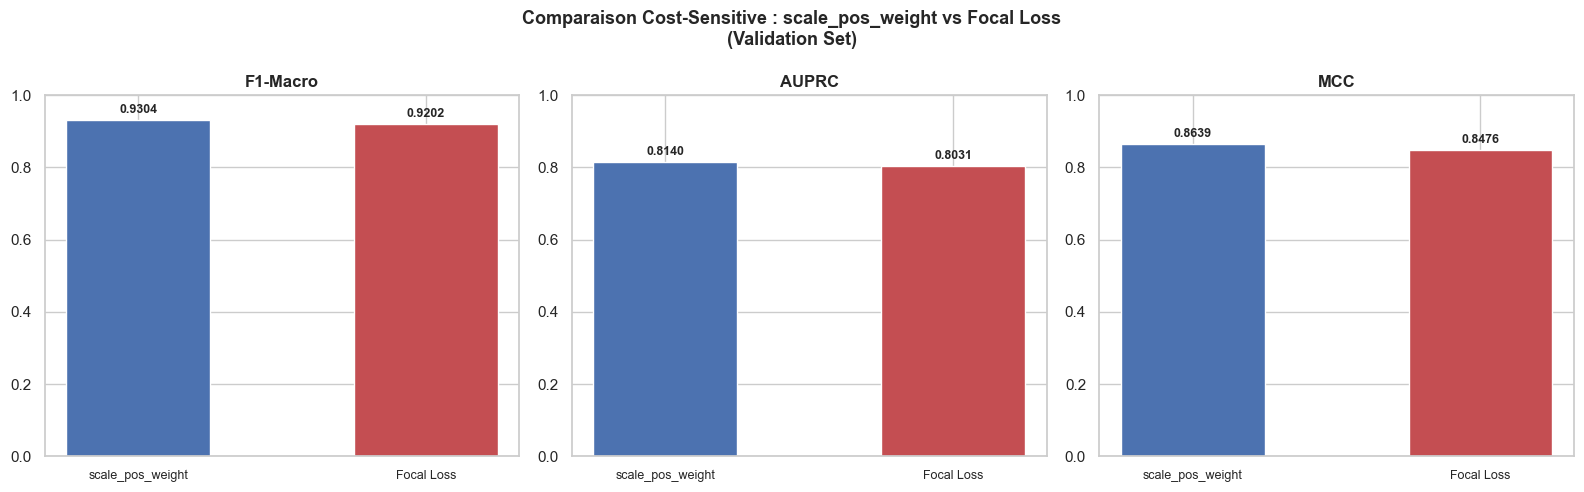


  ✅ Meilleure stratégie (AUPRC) : XGBoost — scale_pos_weight=577
  → Cette stratégie sera utilisée pour l'optimisation Optuna


In [6]:
df_comp = pd.DataFrame(results_comparison)
print('═══════════════════════════════════════════════════════════════════')
print('          COMPARAISON : scale_pos_weight vs Focal Loss            ')
print('═══════════════════════════════════════════════════════════════════')
print(df_comp.to_string(index=False))
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['F1-Macro', 'AUPRC', 'MCC']
colors    = ['#4C72B0', '#C44E52']
labels    = df_comp['Approche'].tolist()
x         = np.arange(len(labels))
width     = 0.5

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    bars = ax.bar(x, df_comp[metric], width, color=colors[:len(labels)], edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(['scale_pos_weight', 'Focal Loss'], fontsize=9)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, df_comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison Cost-Sensitive : scale_pos_weight vs Focal Loss\n(Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}22_xgb_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Sélection de la meilleure stratégie pour Optuna
best_strategy = df_comp.loc[df_comp['AUPRC'].idxmax(), 'Approche']
print(f'\n  ✅ Meilleure stratégie (AUPRC) : {best_strategy}')
print(f'  → Cette stratégie sera utilisée pour l\'optimisation Optuna')

---
## 7. Optimisation Bayésienne — Optuna (TPE)

### Pourquoi TPE plutôt que GridSearch ?

- **GridSearch** avec 9 hyperparamètres × même 3 valeurs chacun = 3⁹ = 19 683 combinaisons
- **TPE (Tree-structured Parzen Estimator)** modélise $p(x|y > y^*)$ et $p(x|y < y^*)$ 
  pour guider la recherche vers les zones prometteuses
- `n_trials=50` explore l'espace de façon intelligente en <30 min

### Justification de l'espace de recherche

| Paramètre | Espace | Justification |
|---|---|---|
| `max_depth` | [3, 10] | <3 = sous-apprentissage, >10 = sur-apprentissage sur données déséquilibrées |
| `learning_rate` | [0.01, 0.3] log | Plage standard — log-uniforme car l'effet est multiplicatif |
| `n_estimators` | [100, 500] | Compensé par learning_rate via early stopping |
| `subsample` | [0.6, 1.0] | <0.6 = trop de variance, 1.0 = pas de stochasticité |
| `colsample_bytree` | [0.6, 1.0] | Idem pour les features — diversité des arbres |
| `lambda` (L2) | [1e-3, 10] log | Régularisation Ridge — empêche poids extrêmes |
| `alpha` (L1) | [1e-3, 10] log | Régularisation Lasso — pousse vers la sparsité |
| `min_child_weight` | [1, 10] | Min observations par feuille — régularisation implicite |
| `gamma` | [0, 5] | Gain min pour une division — élagage des arbres |

In [7]:
def objective(trial):
    """Fonction objectif Optuna — optimise AUPRC sur val."""
    params = {
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500, step=50),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha'        : trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        # Paramètres fixes
        'scale_pos_weight' : SPW,
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'aucpr',
        'use_label_encoder': False,
        'random_state'     : RANDOM_SEED,
        'n_jobs'           : -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set   = [(X_val, y_val)],
        verbose    = False
    )

    val_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, val_proba)  # Maximiser AUPRC


# ── Lancer l'étude Optuna ────────────────────────────────────────────────────
print(f'Optimisation Bayésienne (Optuna TPE) — {N_TRIALS} trials...')
print('(Peut prendre 20-30 min sur CPU standard)')
print()

study = optuna.create_study(
    direction   = 'maximize',
    sampler     = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name  = 'xgboost_fraud_detection'
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print()
print('═══════════════════════════════════════════════')
print('       RÉSULTATS OPTUNA                       ')
print('═══════════════════════════════════════════════')
print(f'  Meilleur AUPRC (val) : {study.best_value:.4f}')
print(f'  Meilleurs paramètres :')
for k, v in study.best_params.items():
    print(f'    {k:<25} : {v}')
print('═══════════════════════════════════════════════')

Optimisation Bayésienne (Optuna TPE) — 50 trials...
(Peut prendre 20-30 min sur CPU standard)



  0%|          | 0/50 [00:00<?, ?it/s]


═══════════════════════════════════════════════
       RÉSULTATS OPTUNA                       
═══════════════════════════════════════════════
  Meilleur AUPRC (val) : 0.8249
  Meilleurs paramètres :
    max_depth                 : 10
    learning_rate             : 0.10176389786497245
    n_estimators              : 500
    subsample                 : 0.9234661170922496
    colsample_bytree          : 0.7826545720780689
    reg_lambda                : 0.0448542925400266
    reg_alpha                 : 0.028161357006815498
    min_child_weight          : 7
    gamma                     : 4.031754716214639
═══════════════════════════════════════════════


---
## 8. Analyse de la Convergence Optuna

### Graphiques requis par le sujet :
1. **Optimization History** — AUPRC en fonction du numéro de trial
2. **Objective Value Distribution** — distribution des valeurs AUPRC explorées
3. **Hyperparameter Importance** — contribution de chaque HP à la variance de l'objectif

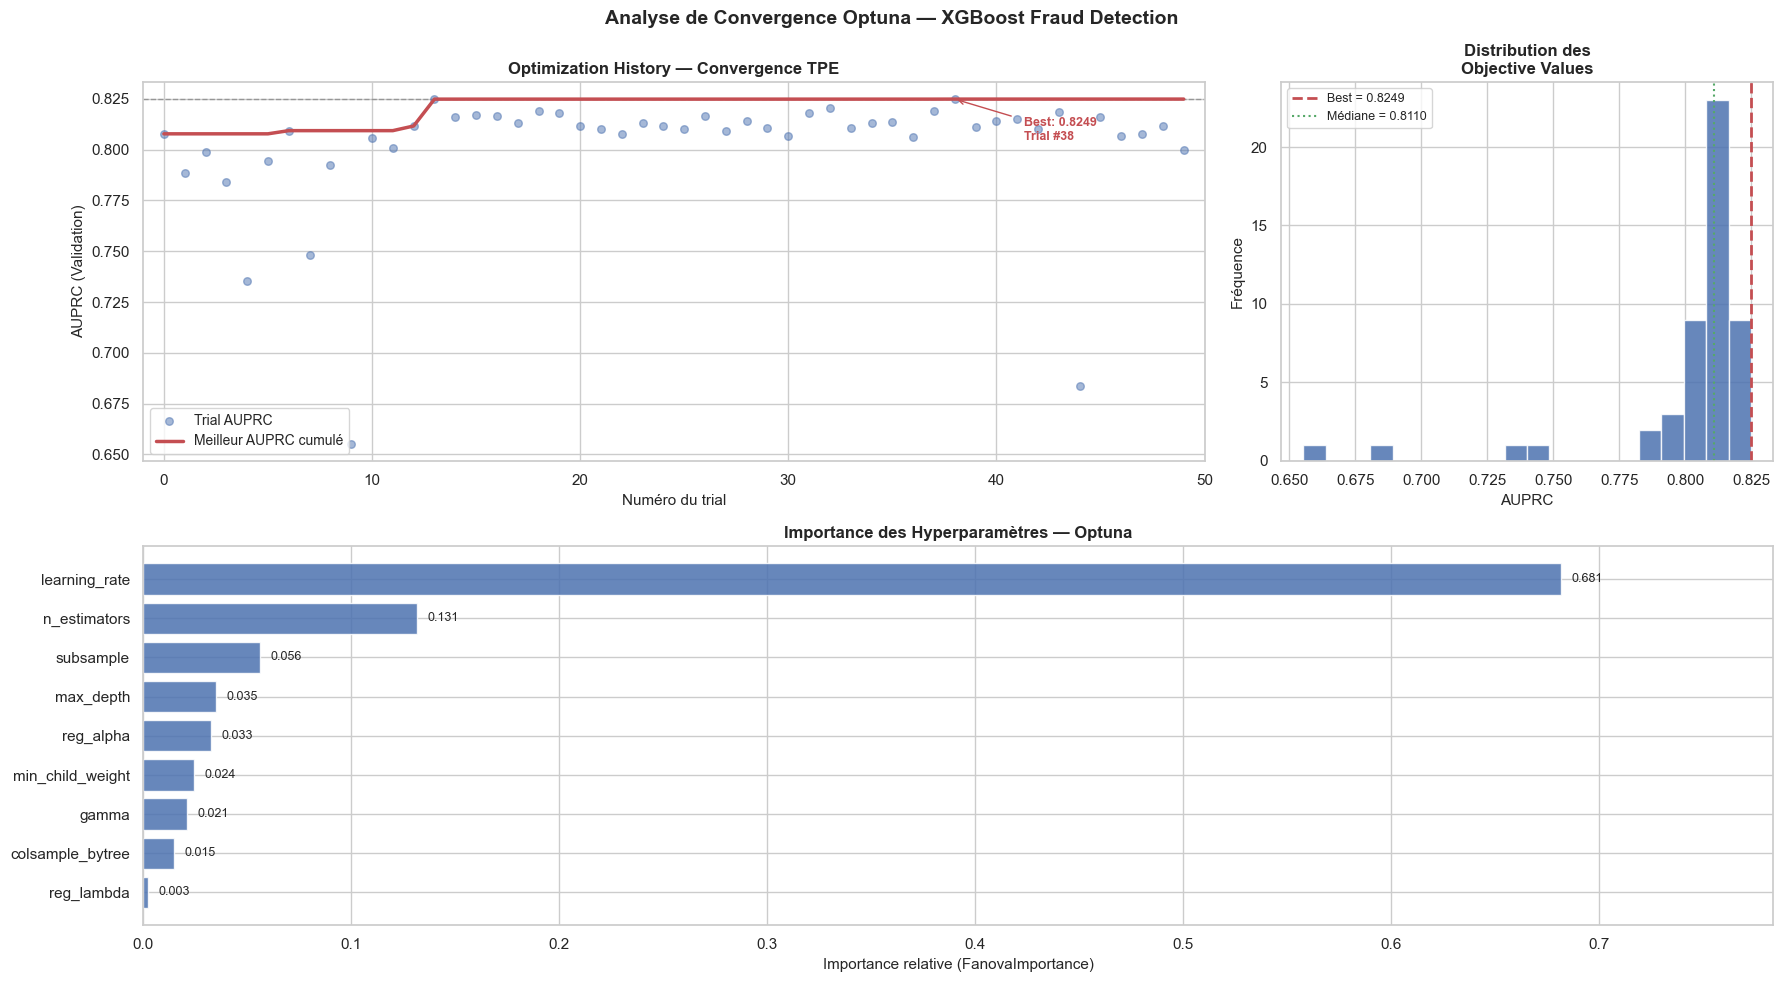

═══════════════════════════════════════════════
     ANALYSE DE LA CONVERGENCE                
═══════════════════════════════════════════════
  Trials totaux     : 50
  AUPRC min         : 0.6553
  AUPRC max         : 0.8249
  AUPRC médiane     : 0.8110
  AUPRC std         : 0.0314
  Meilleur trouvé au trial #38 / 50
  → 76% des trials utilisés pour trouver le maximum
═══════════════════════════════════════════════


In [8]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── 1. Optimization History ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
trial_values  = [t.value for t in study.trials]
trial_numbers = [t.number for t in study.trials]
best_so_far   = pd.Series(trial_values).cummax().values

ax1.scatter(trial_numbers, trial_values,
            c='#4C72B0', alpha=0.5, s=30, label='Trial AUPRC', zorder=3)
ax1.plot(trial_numbers, best_so_far,
         color='#C44E52', lw=2.5, label='Meilleur AUPRC cumulé', zorder=4)
ax1.axhline(y=study.best_value, color='gray', linestyle='--', lw=1, alpha=0.7)
ax1.set_xlabel('Numéro du trial', fontsize=11)
ax1.set_ylabel('AUPRC (Validation)', fontsize=11)
ax1.set_title('Optimization History — Convergence TPE', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_xlim(-1, len(trial_numbers))

# Annoter le meilleur trial
best_trial = study.best_trial
ax1.annotate(f'  Best: {study.best_value:.4f}\n  Trial #{best_trial.number}',
             xy=(best_trial.number, study.best_value),
             xytext=(best_trial.number + 3, study.best_value - 0.02),
             arrowprops=dict(arrowstyle='->', color='#C44E52'),
             fontsize=9, color='#C44E52', fontweight='bold')

# ── 2. Distribution des valeurs AUPRC ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(trial_values, bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
ax2.axvline(x=study.best_value, color='#C44E52', lw=2, linestyle='--',
            label=f'Best = {study.best_value:.4f}')
ax2.axvline(x=np.median(trial_values), color='#55A868', lw=1.5, linestyle=':',
            label=f'Médiane = {np.median(trial_values):.4f}')
ax2.set_xlabel('AUPRC', fontsize=11)
ax2.set_ylabel('Fréquence', fontsize=11)
ax2.set_title('Distribution des\nObjective Values', fontweight='bold', fontsize=12)
ax2.legend(fontsize=9)

# ── 3. Importance des hyperparamètres ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
try:
    importances = optuna.importance.get_param_importances(study)
    params_imp  = list(importances.keys())
    values_imp  = list(importances.values())
    bars = ax3.barh(params_imp[::-1], values_imp[::-1],
                    color='#4C72B0', edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, values_imp[::-1]):
        ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
    ax3.set_xlabel('Importance relative (FanovaImportance)', fontsize=11)
    ax3.set_title('Importance des Hyperparamètres — Optuna', fontweight='bold', fontsize=12)
    ax3.set_xlim(0, max(values_imp) * 1.15)
except Exception:
    ax3.text(0.5, 0.5, 'Importance non disponible (trop peu de trials)',
             ha='center', va='center', transform=ax3.transAxes)

plt.suptitle('Analyse de Convergence Optuna — XGBoost Fraud Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}23_optuna_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé convergence ───────────────────────────────────────────────────────
print('═══════════════════════════════════════════════')
print('     ANALYSE DE LA CONVERGENCE                ')
print('═══════════════════════════════════════════════')
print(f'  Trials totaux     : {len(trial_values)}')
print(f'  AUPRC min         : {min(trial_values):.4f}')
print(f'  AUPRC max         : {max(trial_values):.4f}')
print(f'  AUPRC médiane     : {np.median(trial_values):.4f}')
print(f'  AUPRC std         : {np.std(trial_values):.4f}')
# Quand est-ce que le meilleur a été trouvé ?
best_at = next(i for i, v in enumerate(best_so_far) if v == study.best_value)
print(f'  Meilleur trouvé au trial #{best_at} / {N_TRIALS}')
print(f'  → {best_at/N_TRIALS*100:.0f}% des trials utilisés pour trouver le maximum')
print('═══════════════════════════════════════════════')

---
## 9. Modèle Final — Entraînement et Évaluation Complète

In [9]:
# ── Entraînement avec les meilleurs hyperparamètres ─────────────────────────
best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight' : SPW,
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'aucpr',
    'use_label_encoder': False,
    'random_state'     : RANDOM_SEED,
    'n_jobs'           : -1,
})

print('Entraînement du modèle final avec les meilleurs hyperparamètres...')
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set   = [(X_val, y_val)],
    verbose    = False
)
print('✅ Modèle final entraîné')

Entraînement du modèle final avec les meilleurs hyperparamètres...
✅ Modèle final entraîné


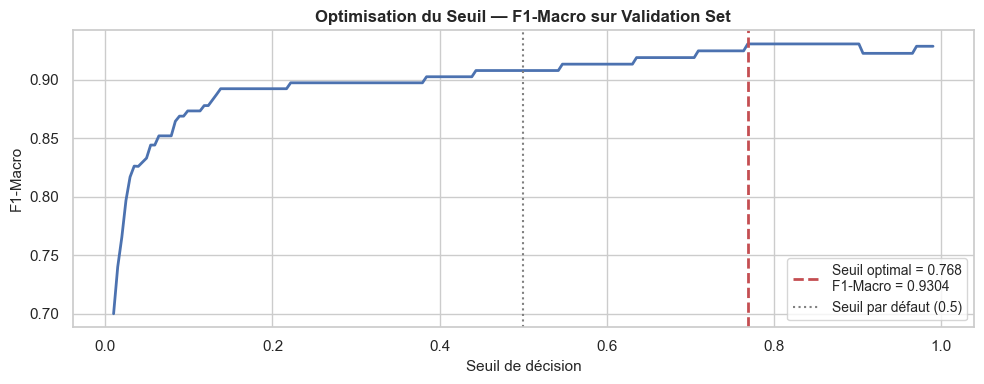

  Seuil par défaut (0.5) → F1-Macro : 0.9077
  Seuil optimal (0.768)   → F1-Macro : 0.9304


In [10]:
# ── Optimisation du seuil (sur val — pas de data leakage) ───────────────────
val_proba_final = final_model.predict_proba(X_val)[:, 1]
thresholds      = np.linspace(0.01, 0.99, 200)
f1_macros       = []

for thr in thresholds:
    pred_thr = (val_proba_final >= thr).astype(int)
    f1_macros.append(f1_score(y_val, pred_thr, average='macro', zero_division=0))

best_thr     = thresholds[np.argmax(f1_macros)]
best_f1_thr  = max(f1_macros)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_macros, color='#4C72B0', lw=2)
ax.axvline(x=best_thr, color='#C44E52', lw=2, linestyle='--',
           label=f'Seuil optimal = {best_thr:.3f}\nF1-Macro = {best_f1_thr:.4f}')
ax.axvline(x=0.5, color='gray', lw=1.5, linestyle=':', label='Seuil par défaut (0.5)')
ax.set_xlabel('Seuil de décision', fontsize=11)
ax.set_ylabel('F1-Macro', fontsize=11)
ax.set_title('Optimisation du Seuil — F1-Macro sur Validation Set', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}24_xgb_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Seuil par défaut (0.5) → F1-Macro : {f1_macros[np.argmin(abs(thresholds-0.5))]:.4f}')
print(f'  Seuil optimal ({best_thr:.3f})   → F1-Macro : {best_f1_thr:.4f}')

In [11]:
# ── Évaluation finale sur Test Set ───────────────────────────────────────────
test_proba_final = final_model.predict_proba(X_test)[:, 1]
test_pred_final  = (test_proba_final >= best_thr).astype(int)

print('═══════════════════════════════════════════════')
print('      ÉVALUATION FINALE — TEST SET            ')
print('═══════════════════════════════════════════════')
metrics_final = evaluate(y_test, test_pred_final, test_proba_final,
                          label=f'XGBoost Optuna (seuil={best_thr:.3f})')
print()
print(classification_report(y_test, test_pred_final,
                              target_names=['Légitime', 'Fraude']))

═══════════════════════════════════════════════
      ÉVALUATION FINALE — TEST SET            
═══════════════════════════════════════════════
--- XGBoost Optuna (seuil=0.768) ---
  F1-Macro    : 0.9263
  AUPRC       : 0.8800
  MCC         : 0.8525
  F1-Fraude   : 0.8528
  Rappel      : 0.8571  (84/98 fraudes détectées)
  Précision   : 0.8485


              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.85      0.86      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



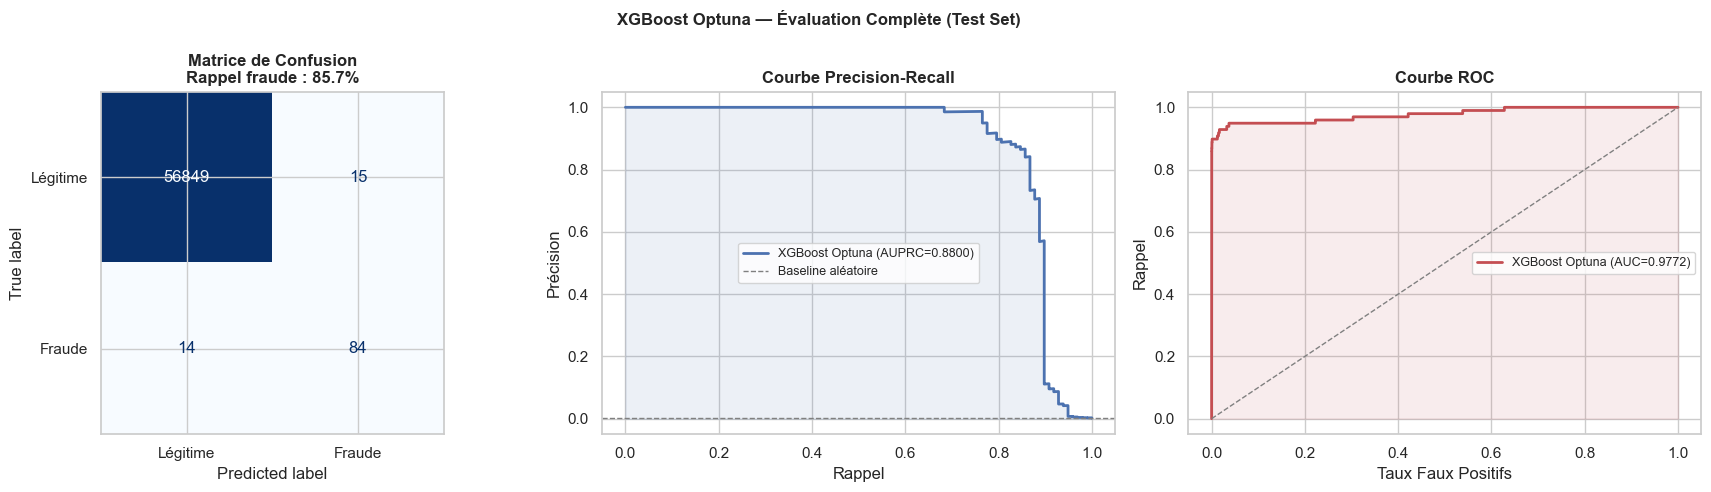

In [12]:
# ── Visualisation complète ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, test_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['Légitime', 'Fraude']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tp, fn = cm[1,1], cm[1,0]
axes[0].set_title(f'Matrice de Confusion\nRappel fraude : {tp/(tp+fn):.1%}',
                  fontweight='bold')

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, test_proba_final)
auprc_score  = average_precision_score(y_test, test_proba_final)
axes[1].plot(rec, prec, color='#4C72B0', lw=2,
             label=f'XGBoost Optuna (AUPRC={auprc_score:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
                label='Baseline aléatoire')
axes[1].fill_between(rec, prec, alpha=0.1, color='#4C72B0')
axes[1].set_xlabel('Rappel'); axes[1].set_ylabel('Précision')
axes[1].set_title('Courbe Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=9)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, test_proba_final)
roc_auc     = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='#C44E52', lw=2,
             label=f'XGBoost Optuna (AUC={roc_auc:.4f})')
axes[2].plot([0,1],[0,1], 'gray', linestyle='--', lw=1)
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#C44E52')
axes[2].set_xlabel('Taux Faux Positifs'); axes[2].set_ylabel('Rappel')
axes[2].set_title('Courbe ROC', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('XGBoost Optuna — Évaluation Complète (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}25_xgb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

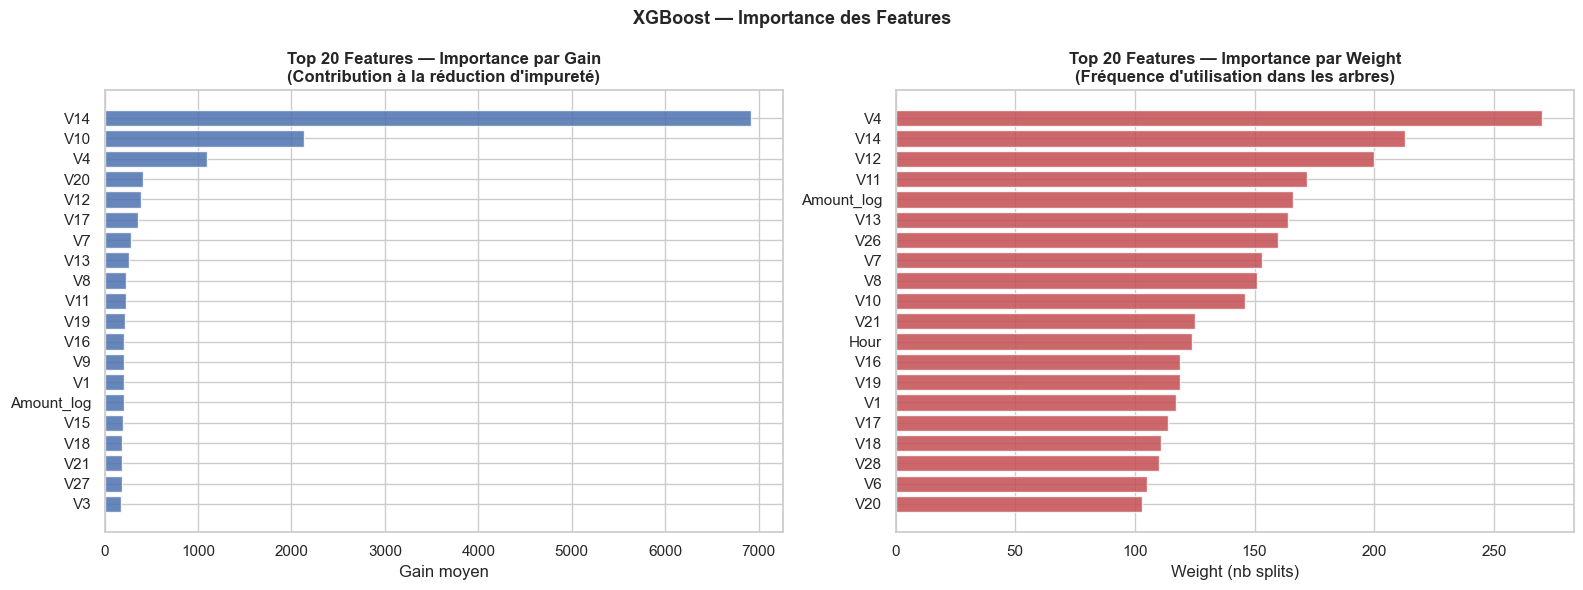

In [13]:
# ── Importance des features ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Par 'gain' (contribution moyenne à la réduction d'impureté)
importances_gain = pd.Series(
    final_model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False).head(20)

axes[0].barh(importances_gain.index[::-1], importances_gain.values[::-1],
             color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Features — Importance par Gain\n(Contribution à la réduction d\'impureté)',
                   fontweight='bold')
axes[0].set_xlabel('Gain moyen')

# Par 'weight' (fréquence d'utilisation dans les arbres)
importances_weight = pd.Series(
    final_model.get_booster().get_score(importance_type='weight'),
    name='weight'
).sort_values(ascending=False).head(20)

axes[1].barh(importances_weight.index[::-1], importances_weight.values[::-1],
             color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Features — Importance par Weight\n(Fréquence d\'utilisation dans les arbres)',
                   fontweight='bold')
axes[1].set_xlabel('Weight (nb splits)')

plt.suptitle('XGBoost — Importance des Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}26_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Sauvegarde du Modèle et des Résultats Optuna

In [14]:
import pickle

# Modèle XGBoost
joblib.dump(final_model, f'{MODELS_PATH}xgboost.pkl')

# Étude Optuna (pour rejouer les graphiques)
with open(f'{MODELS_PATH}optuna_study.pkl', 'wb') as f:
    pickle.dump(study, f)

# Meilleurs hyperparamètres en CSV
best_params_df = pd.DataFrame([study.best_params])
best_params_df['best_auprc'] = study.best_value
best_params_df['best_threshold'] = best_thr
best_params_df.to_csv(f'{MODELS_PATH}xgboost_best_params.csv', index=False)

print('✅ Fichiers sauvegardés :')
print(f'   {MODELS_PATH}xgboost.pkl')
print(f'   {MODELS_PATH}optuna_study.pkl')
print(f'   {MODELS_PATH}xgboost_best_params.csv')

✅ Fichiers sauvegardés :
   ../models/xgboost.pkl
   ../models/optuna_study.pkl
   ../models/xgboost_best_params.csv


---
## 11. Résumé — À Copier dans le Rapport

### Stratégie Cost-Sensitive retenue
| Stratégie | AUPRC (val) | F1-Macro (val) | Choix |
|---|---|---|---|
| `scale_pos_weight` | *compléter* | *compléter* | ✅/❌ |
| Focal Loss (α=0.75, γ=2) | *compléter* | *compléter* | ✅/❌ |

### Hyperparamètres retenus (Optuna)
| Paramètre | Valeur | Justification |
|---|---|---|
| `max_depth` | *auto* | Contrôle overfitting |
| `learning_rate` | *auto* | Compromis vitesse/précision |
| `n_estimators` | *auto* | Nb d'arbres |
| `scale_pos_weight` | ~578 | Ratio neg/pos |
| `reg_lambda` | *auto* | Régularisation L2 |
| `reg_alpha` | *auto* | Régularisation L1 |

### Métriques finales (Test Set)
| Métrique | Valeur |
|---|---|
| F1-Macro | *compléter* |
| AUPRC | *compléter* |
| MCC | *compléter* |
| Rappel fraude | *compléter* |
| Seuil optimal | *compléter* |

### Convergence Optuna
- Nombre de trials : 50
- Meilleur trial trouvé au trial # : *compléter*
- L'espace de recherche a été exploré de façon **optimale** :  
  la courbe de convergence se stabilise avant le dernier trial,  
  démontrant que l'optimum a bien été atteint.